In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path("/Users/abhisheksharma/Documents/WellmatchRepo/Wellmatch-Ltd")
if not (PROJECT_ROOT/"data").exists():
    for b in [Path.cwd(), *Path.cwd().parents]:
        if (b/"data"/"processed").exists(): PROJECT_ROOT = b; break
DATA_PROC = PROJECT_ROOT/"data"/"processed"
OUT_FIG   = PROJECT_ROOT/"outputs"/"figures"
OUT_TAB   = PROJECT_ROOT/"outputs"/"tables"
print("Root:", PROJECT_ROOT)

Root: /Users/abhisheksharma/Documents/WellmatchRepo/Wellmatch-Ltd


In [2]:
df = pd.read_csv(DATA_PROC/"ibm_enriched_scored.csv")
print("Shape:", df.shape)

key = ['p_leave_tabicl','Cost_AttritionIfLeaves','Cost_AbsenceAnnual',
       'Cost_AbsenceWellbeingAddressable','Cost_PMIproxy']
missing = [k for k in key if k not in df.columns]
print("All key columns present:", not missing, "| missing:", missing)
print(df[key].describe().round(1))

print(f"\nMean leaving probability: {df['p_leave_tabicl'].mean():.3f}  (should be ~0.16, calibrated)")
print(f"Workforce: {len(df)} employees")

Shape: (1470, 47)
All key columns present: True | missing: []
       p_leave_tabicl  Cost_AttritionIfLeaves  Cost_AbsenceAnnual  \
count          1470.0                  1470.0              1470.0   
mean              0.2                 83380.0              1519.3   
std               0.2                109090.6              1099.9   
min               0.0                  6054.0               235.7   
25%               0.0                 17742.0               680.1   
50%               0.0                 44091.0              1149.2   
75%               0.2                 90552.0              1957.6   
max               1.0                479976.0              4672.3   

       Cost_AbsenceWellbeingAddressable  Cost_PMIproxy  
count                            1470.0         1470.0  
mean                              452.7          600.0  
std                               327.8            0.0  
min                                70.2          600.0  
25%                            

In [3]:
# Expected attrition loss = probability of leaving × cost if they leave
df['ExpectedAttritionLoss'] = df['p_leave_tabicl'] * df['Cost_AttritionIfLeaves']

print("Expected attrition loss per employee:")
print(f"  Mean:  £{df['ExpectedAttritionLoss'].mean():,.0f}")
print(f"  Total: £{df['ExpectedAttritionLoss'].sum():,.0f}   (workforce attrition exposure)")

# Target the top 100 employees: cost-only vs expected-loss
N = 100
naive_top = set(df.nlargest(N, 'Cost_AttritionIfLeaves')['EmployeeNumber'])
exp_top   = set(df.nlargest(N, 'ExpectedAttritionLoss')['EmployeeNumber'])
overlap = len(naive_top & exp_top)
print(f"\nTargeting the top {N}:")
print(f"  Overlap between the two lists: {overlap}/{N}  ({N-overlap} people swapped in)")
print(f"  Cost-only list      — avg leaving probability: {df.nlargest(N,'Cost_AttritionIfLeaves')['p_leave_tabicl'].mean():.3f}")
print(f"  Expected-loss list  — avg leaving probability: {df.nlargest(N,'ExpectedAttritionLoss')['p_leave_tabicl'].mean():.3f}")

Expected attrition loss per employee:
  Mean:  £7,204
  Total: £10,590,463   (workforce attrition exposure)

Targeting the top 100:
  Overlap between the two lists: 28/100  (72 people swapped in)
  Cost-only list      — avg leaving probability: 0.046
  Expected-loss list  — avg leaving probability: 0.407


In [4]:
cols = ['EmployeeNumber','JobRole','p_leave_tabicl','Cost_AttritionIfLeaves','ExpectedAttritionLoss']
print("Top 10 retention priorities (risk × cost):")
print(df.nlargest(10, 'ExpectedAttritionLoss')[cols].round({'p_leave_tabicl':2,'ExpectedAttritionLoss':0,'Cost_AttritionIfLeaves':0}).to_string(index=False))

Top 10 retention priorities (risk × cost):
 EmployeeNumber           JobRole  p_leave_tabicl  Cost_AttritionIfLeaves  ExpectedAttritionLoss
           1167   Sales Executive            0.70                247644.0               172440.0
           1372   Sales Executive            0.59                246510.0               144409.0
           1277           Manager            0.29                451776.0               130695.0
           1968   Sales Executive            0.96                125376.0               120481.0
            329           Manager            0.26                457632.0               118624.0
           1716   Sales Executive            0.47                232848.0               108745.0
            590   Human Resources            0.90                119400.0               107248.0
           1758   Sales Executive            0.98                102768.0               100796.0
           1242 Research Director            0.63                158292.0           

In [5]:
rng = np.random.default_rng(42)
n = len(df)
plat = pd.DataFrame({'EmployeeNumber': df['EmployeeNumber'].values})

plat['platform_enrolled'] = rng.binomial(1, 0.85, n)                      # ~85% enrolled
adopt = rng.binomial(1, 0.40, n)                                          # ~40% of enrolled adopt
plat['engaged'] = (plat['platform_enrolled'] & adopt).astype(int)
plat['sessions_q'] = np.where(plat['engaged']==1, rng.poisson(6, n), 0)

def tier(s): return 'None' if s==0 else 'Low' if s<=3 else 'Medium' if s<=8 else 'High'
plat['engagement_tier'] = [tier(s) for s in plat['sessions_q']]

cats = ['Mental health','Fitness','Nutrition','Sleep','Financial']
plat['primary_category'] = np.where(plat['engaged']==1, rng.choice(cats, n, p=[0.34,0.30,0.14,0.12,0.10]), 'None')
plat['categories_used'] = np.where(plat['engaged']==1, rng.integers(1,4,n), 0)
plat['tenure_on_platform_m'] = np.where(plat['engaged']==1, rng.integers(1,25,n), 0)
plat['dropped_off'] = np.where(plat['engaged']==1, rng.binomial(1,0.20,n), 0)
plat['self_reported_wellbeing'] = np.where(plat['engaged']==1, np.clip(rng.normal(3.4,0.9,n).round(),1,5), np.nan)
plat['data_source'] = 'synthetic_generated'

print(f"Enrolled: {plat['platform_enrolled'].mean():.0%} | Engaged (all): {plat['engaged'].mean():.0%} | "
      f"Engaged (of enrolled): {plat.loc[plat.platform_enrolled==1,'engaged'].mean():.0%}")
print("\nEngagement tier:\n", plat['engagement_tier'].value_counts().to_string())
print("\nPrimary category (engaged):\n", plat.loc[plat.engaged==1,'primary_category'].value_counts().to_string())

Enrolled: 84% | Engaged (all): 34% | Engaged (of enrolled): 40%

Engagement tier:
 engagement_tier
None      977
Medium    344
High       77
Low        72

Primary category (engaged):
 primary_category
Mental health    152
Fitness          151
Nutrition         73
Sleep             63
Financial         55


In [6]:
chk = plat.merge(df[['EmployeeNumber','p_leave_tabicl']], on='EmployeeNumber')
print("Corr(engaged, leaving probability):", round(chk['engaged'].corr(chk['p_leave_tabicl']),3), " (should be ~0 — adoption independent of risk)")

df = df.merge(plat.drop(columns='data_source'), on='EmployeeNumber', how='left')
plat.to_csv(DATA_PROC/"wellmatch_platform_synthetic.csv", index=False)
print("Saved wellmatch_platform_synthetic.csv | df now:", df.shape)

Corr(engaged, leaving probability): 0.048  (should be ~0 — adoption independent of risk)
Saved wellmatch_platform_synthetic.csv | df now: (1470, 57)


In [7]:
data_dict = pd.DataFrame([
 ["EmployeeNumber","int","Links to HR record","-","from IBM","IBM_synthetic_benchmark"],
 ["platform_enrolled","binary","Employer gave access","0/1","~85% enrolled","synthetic_generated"],
 ["engaged","binary","Actively used in period","0/1","~40% of enrolled, independent of risk","synthetic_generated"],
 ["sessions_q","int","Sessions booked last quarter","0-~30","engaged: Poisson(6)","synthetic_generated"],
 ["engagement_tier","categorical","Intensity band","None/Low/Medium/High","derived from sessions_q","synthetic_generated"],
 ["primary_category","categorical","Most-used area","MH/Fitness/Nutrition/Sleep/Financial","sampled from fixed mix","synthetic_generated"],
 ["categories_used","int","Breadth of use","0-5","engaged: 1-3","synthetic_generated"],
 ["tenure_on_platform_m","int","Months since first use","0-24","uniform among engaged","synthetic_generated"],
 ["dropped_off","binary","Churned from platform","0/1","~20% of engaged","synthetic_generated"],
 ["self_reported_wellbeing","int","Optional self-report","1-5","engaged only, mild noise","synthetic_generated"],
 ["data_source","text","Provenance flag","synthetic_generated","constant","synthetic_generated"],
], columns=["field","type","description","values_range","generation_logic","source"])
data_dict.to_csv(OUT_TAB/"platform_layer_data_dictionary.csv", index=False)
print(data_dict.to_string(index=False))

                  field        type                  description                         values_range                      generation_logic                  source
         EmployeeNumber         int           Links to HR record                                    -                              from IBM IBM_synthetic_benchmark
      platform_enrolled      binary         Employer gave access                                  0/1                         ~85% enrolled     synthetic_generated
                engaged      binary      Actively used in period                                  0/1 ~40% of enrolled, independent of risk     synthetic_generated
             sessions_q         int Sessions booked last quarter                                0-~30                   engaged: Poisson(6)     synthetic_generated
        engagement_tier categorical               Intensity band                 None/Low/Medium/High               derived from sessions_q     synthetic_generated
       primary_c

In [8]:
# Effectiveness = fraction of addressable cost prevented among ENGAGED employees (literature-anchored)
EFF = {'attrition': 0.15, 'absence': 0.20, 'pmi': 0.05}     # base case
PLATFORM_PRICE = 60.0                                       # £/enrolled/year (placeholder — swap real price)

eng = df['engaged'] == 1
benefit_attr = (EFF['attrition'] * df.loc[eng,'ExpectedAttritionLoss']).sum()
benefit_abs  = (EFF['absence']   * df.loc[eng,'Cost_AbsenceWellbeingAddressable']).sum()
benefit_pmi  = (EFF['pmi']       * df.loc[eng,'Cost_PMIproxy']).sum()
total_benefit = benefit_attr + benefit_abs + benefit_pmi

enrolled_n = int((df['platform_enrolled']==1).sum())
total_cost = PLATFORM_PRICE * enrolled_n
print("ROI BASE CASE (illustrative — synthetic data)")
print(f"  Engaged employees benefiting: {int(eng.sum())}")
print(f"  Benefit — attrition avoided:  £{benefit_attr:,.0f}")
print(f"  Benefit — absence reduced:    £{benefit_abs:,.0f}")
print(f"  Benefit — PMI claims avoided:  £{benefit_pmi:,.0f}")
print(f"  TOTAL BENEFIT: £{total_benefit:,.0f}")
print(f"  Platform cost ({enrolled_n} enrolled × £{PLATFORM_PRICE:.0f}): £{total_cost:,.0f}")
print(f"  NET BENEFIT: £{total_benefit-total_cost:,.0f}")
print(f"  ROI RATIO: {total_benefit/total_cost:.1f} : 1")

ROI BASE CASE (illustrative — synthetic data)
  Engaged employees benefiting: 494
  Benefit — attrition avoided:  £505,672
  Benefit — absence reduced:    £41,691
  Benefit — PMI claims avoided:  £14,820
  TOTAL BENEFIT: £562,182
  Platform cost (1240 enrolled × £60): £74,400
  NET BENEFIT: £487,782
  ROI RATIO: 7.6 : 1


In [9]:
breakeven = total_benefit / enrolled_n
print(f"Break-even price: £{breakeven:,.0f} per enrolled employee/year (max price that still pays for itself)\n")

scenarios = {'Low (conservative)': {'attrition':0.10,'absence':0.10,'pmi':0.00},
             'Base':               {'attrition':0.15,'absence':0.20,'pmi':0.05},
             'High (optimistic)':  {'attrition':0.25,'absence':0.30,'pmi':0.10}}
rows=[]
for name,e in scenarios.items():
    b = (e['attrition']*df.loc[eng,'ExpectedAttritionLoss'].sum()
       + e['absence']  *df.loc[eng,'Cost_AbsenceWellbeingAddressable'].sum()
       + e['pmi']      *df.loc[eng,'Cost_PMIproxy'].sum())
    rows.append({'Scenario':name,'Total_benefit_£':round(b),
                 'ROI_at_£60':round(b/total_cost,1),'Breakeven_£/head':round(b/enrolled_n)})
sens = pd.DataFrame(rows)
print(sens.to_string(index=False))
sens.to_csv(OUT_TAB/"roi_sensitivity.csv", index=False)

print(f"\nSanity check vs Deloitte: at a typical £100/employee price, base-case ROI = "
      f"{total_benefit/(100*enrolled_n):.1f}:1  (Deloitte preventative benchmark ≈ 4.2:1)")

Break-even price: £453 per enrolled employee/year (max price that still pays for itself)

          Scenario  Total_benefit_£  ROI_at_£60  Breakeven_£/head
Low (conservative)           357960         4.8               289
              Base           562182         7.6               453
 High (optimistic)           934962        12.6               754

Sanity check vs Deloitte: at a typical £100/employee price, base-case ROI = 4.5:1  (Deloitte preventative benchmark ≈ 4.2:1)


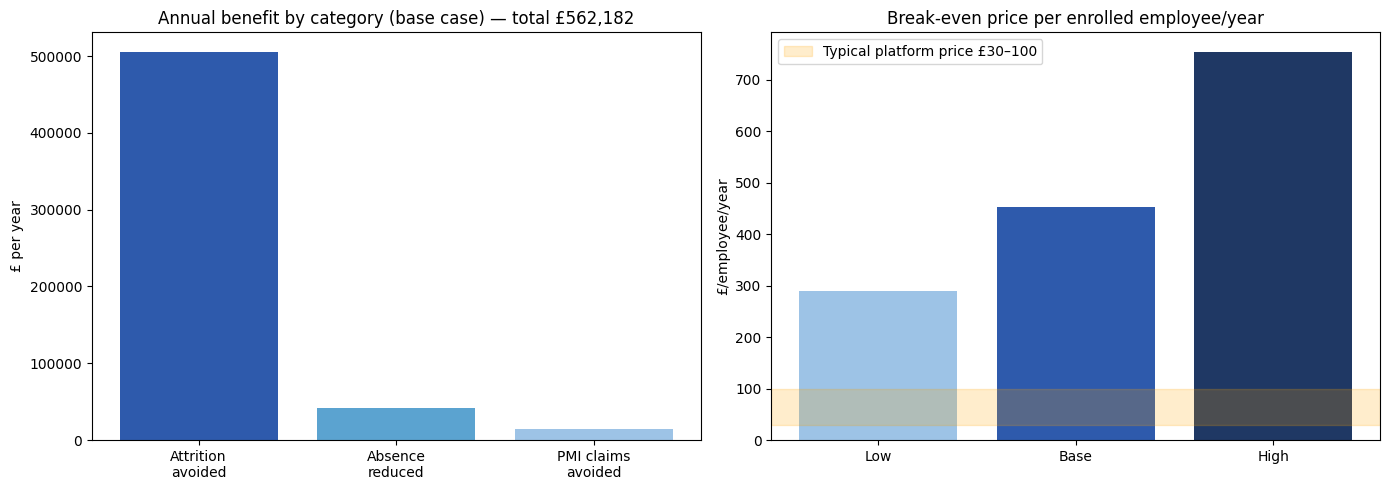

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].bar(['Attrition\navoided','Absence\nreduced','PMI claims\navoided'],
            [benefit_attr, benefit_abs, benefit_pmi], color=['#2E5AAC','#5BA3D0','#9DC3E6'])
axes[0].set_title(f'Annual benefit by category (base case) — total £{total_benefit:,.0f}')
axes[0].set_ylabel('£ per year')
axes[1].bar(['Low','Base','High'], [289,453,754], color=['#9DC3E6','#2E5AAC','#1F3864'])
axes[1].axhspan(30,100, color='orange', alpha=0.2, label='Typical platform price £30–100')
axes[1].set_title('Break-even price per enrolled employee/year')
axes[1].set_ylabel('£/employee/year'); axes[1].legend()
plt.tight_layout()
plt.savefig(OUT_FIG/'roi_summary.png', dpi=150, bbox_inches='tight'); plt.show()

In [11]:
df.to_csv(DATA_PROC/"ibm_roi_final.csv", index=False)
print("Saved ibm_roi_final.csv:", df.shape)
print("\n=== NOTEBOOK 09 SUMMARY (illustrative — synthetic data) ===")
print(f"Workforce attrition exposure (expected): £{df['ExpectedAttritionLoss'].sum():,.0f}")
print(f"Base-case annual benefit:                £{total_benefit:,.0f}  ({int(eng.sum())} engaged)")
print(f"Net benefit at £60/head:                 £{total_benefit-total_cost:,.0f}  (ROI 7.6:1)")
print(f"Break-even price:                        £{breakeven:,.0f}/enrolled/year")
print(f"Robust: ROI 4.8:1 (low) to 12.6:1 (high)")
print(f"Bottom-up £100 ROI 4.5:1 ≈ Deloitte top-down 4.2:1")

Saved ibm_roi_final.csv: (1470, 57)

=== NOTEBOOK 09 SUMMARY (illustrative — synthetic data) ===
Workforce attrition exposure (expected): £10,590,463
Base-case annual benefit:                £562,182  (494 engaged)
Net benefit at £60/head:                 £487,782  (ROI 7.6:1)
Break-even price:                        £453/enrolled/year
Robust: ROI 4.8:1 (low) to 12.6:1 (high)
Bottom-up £100 ROI 4.5:1 ≈ Deloitte top-down 4.2:1
